# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [3]:
df = pd.read_csv('data/reviews_sentiment.csv', sep=';')
df = df[['wordcount', 'sentimentValue', 'Star Rating']]
df.head()

,wordcount,sentimentValue,Star Rating
0,23,-0.486389,1
1,20,-0.586187,1
2,4,-0.602240,1
3,17,-0.616271,1
4,6,-0.651784,1


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

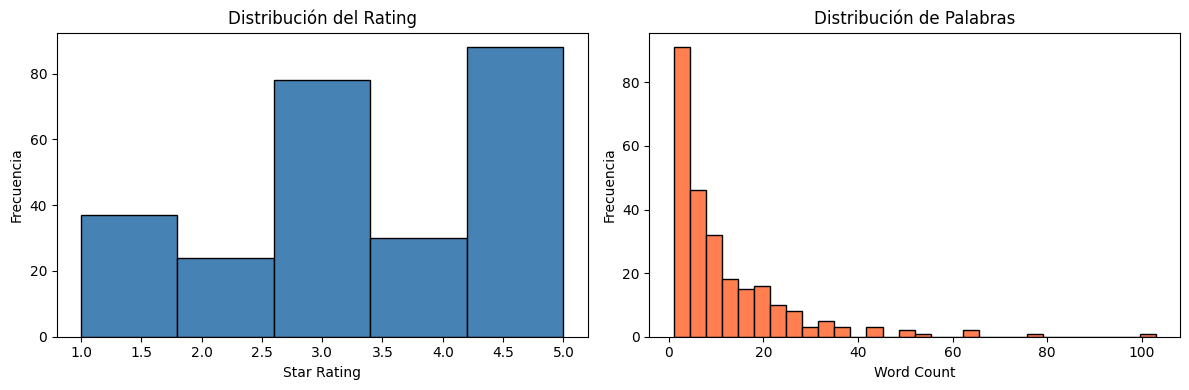

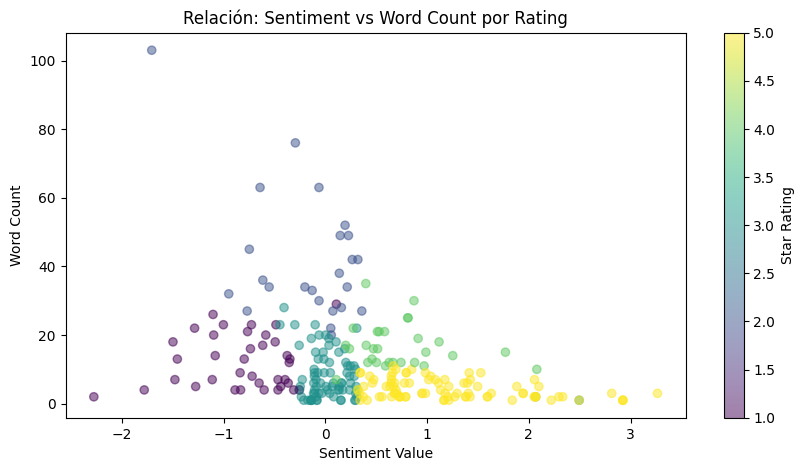

In [4]:
# Análisis univariante - Distribución del rating
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de las estrellas
axes[0].hist(df['Star Rating'], bins=5, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Rating')

# Distribución de wordcount
axes[1].hist(df['wordcount'], bins=30, edgecolor='black', color='coral')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Palabras')

plt.tight_layout()
plt.show()

# Relación entre variables
plt.figure(figsize=(10, 5))
plt.scatter(df['sentimentValue'], df['wordcount'], c=df['Star Rating'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Star Rating')
plt.xlabel('Sentiment Value')
plt.ylabel('Word Count')
plt.title('Relación: Sentiment vs Word Count por Rating')
plt.show()

Text(0.5, 1.02, 'Relaciones entre Variables')

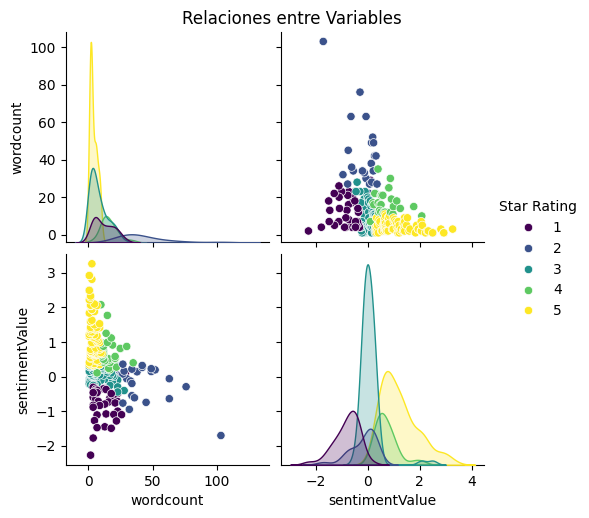

In [5]:
sns.pairplot(df, hue='Star Rating', palette='viridis')
plt.suptitle('Relaciones entre Variables', y=1.02)

In [6]:
df.corr()

,wordcount,sentimentValue,Star Rating
wordcount,1.000000,-0.347232,-0.402059
sentimentValue,-0.347232,1.000000,0.792180
Star Rating,-0.402059,0.792180,1.000000


## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Separamos features y target
X = df.drop('Star Rating', axis=1)
y = df['Star Rating']

# Dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos las features al rango [0, 1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

Train: (205, 2)
Test: (52, 2)


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# Creamos el modelo KNN con k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

train_score = knn.score(X_train_scaled, y_train)
test_score = knn.score(X_test_scaled, y_test)

print(f"Accuracy Train: {train_score:.4f}")
print(f"Accuracy Test: {test_score:.4f}")

Accuracy Train: 0.9171
Accuracy Test: 0.8269


## Evalúa tu modelo

Matriz de Confusión:

Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.80      0.84        10
           2       0.40      1.00      0.57         2
           3       0.75      0.86      0.80        14
           4       1.00      0.29      0.44         7
           5       0.85      0.89      0.87        19

    accuracy                           0.79        52
   macro avg       0.78      0.77      0.71        52
weighted avg       0.83      0.79      0.78        52



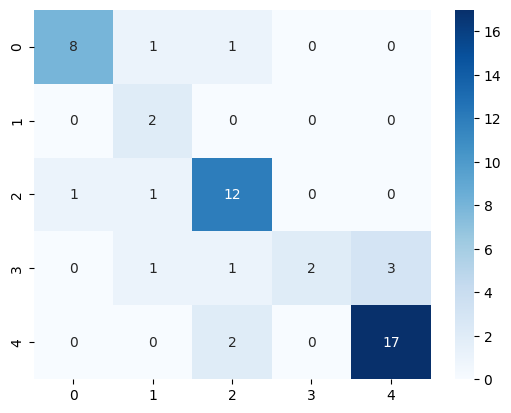

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones
y_pred = knn.predict(X_test_scaled)

# Matriz de confusión
print("Matriz de Confusión:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

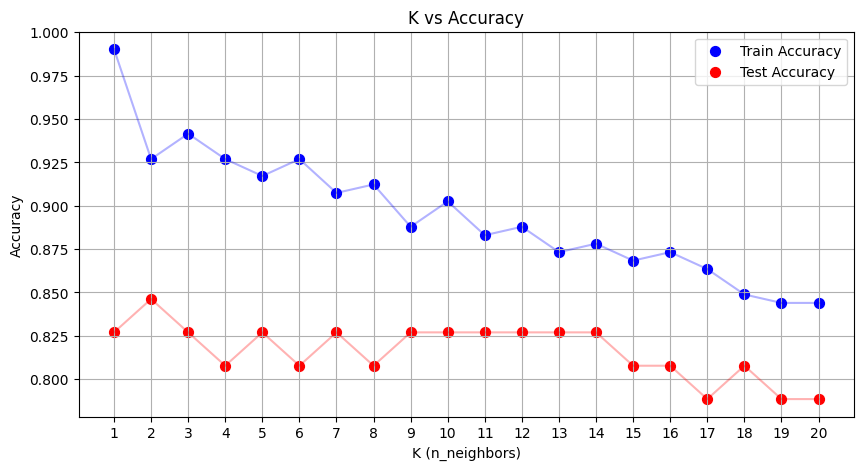

Mejor k: 2 con accuracy en test: 0.8462


In [10]:
# Probamos diferentes valores de k y calculamos su accuracy
k_values = range(1, 21)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Scatterplot: k vs accuracy
plt.figure(figsize=(10, 5))
plt.scatter(k_values, train_accuracies, color='blue', label='Train Accuracy', s=50)
plt.scatter(k_values, test_accuracies, color='red', label='Test Accuracy', s=50)
plt.plot(k_values, train_accuracies, color='blue', alpha=0.3)
plt.plot(k_values, test_accuracies, color='red', alpha=0.3)
plt.xlabel('K (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Mejor k
best_k = k_values[np.argmax(test_accuracies)]
best_acc = max(test_accuracies)
print(f"Mejor k: {best_k} con accuracy en test: {best_acc:.4f}")

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [11]:
# Nueva review: 5 palabras, sentimiento = 1
nueva_review = np.array([[5, 1]])

# Escalar usando el mismo scaler
nueva_review_scaled = scaler.transform(nueva_review)

# Predecir con el mejor modelo
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
prediccion = knn_best.predict(nueva_review_scaled)

print(f"Nueva review: wordcount=5, sentimentValue=1")
print(f"Predicción de rating: {prediccion[0]}")

Nueva review: wordcount=5, sentimentValue=1
Predicción de rating: 5


c:\Users\rns_2\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
